# E1 + Scaling

Train Transformer-small vs Hyena-small (WikiText-2) → `results/*.csv` + plot.

**Dùng:** Runtime → T4 GPU → Run all (~5–10 phút, cuối notebook tải `results.zip`).

## 1. Kiểm tra GPU

In [15]:
!nvidia-smi -L
import torch
print('torch', torch.__version__, '| CUDA available:', torch.cuda.is_available())
assert torch.cuda.is_available(), 'CHƯA bật GPU! Vào Runtime > Change runtime type > T4 GPU rồi Run all lại.'

GPU 0: Tesla T4 (UUID: GPU-c15e1398-7441-c424-4128-bbb8e7c36e1f)
torch 2.11.0+cu128 | CUDA available: True


## 2. Clone repo + cài thư viện
Thêm `datasets` + `transformers` (các lib khác đã có sẵn trên Colab).

In [16]:
%cd /content
![ -d CS2308-Hyena-Hierarchy-Long-Context-NLP ] || git clone https://github.com/minhtien0498/CS2308-Hyena-Hierarchy-Long-Context-NLP.git
%cd CS2308-Hyena-Hierarchy-Long-Context-NLP
!git pull -q
# Pin version để tránh HfUriError (datasets/hub mới đổi quy ước tên dataset)
!pip install -q "datasets<3" "huggingface_hub<0.26" transformers

/content
/content/CS2308-Hyena-Hierarchy-Long-Context-NLP


## 3. E1 — Train PPL (L=256)
5 epoch cho nhanh (tăng `--epochs 20` nếu muốn PPL đẹp hơn). Lưu `results/E1_*_L256.csv`.

In [17]:
!python train.py --model transformer --seq_len 256 --epochs 5 --batch_size 16

[Device] GPU: Tesla T4

  Run: transformer_L256_20260614_162052
  Model: transformer | Seq len: 256
  Epochs: 5 | Batch size: 16

[Data] Loading train dataloader...
[Tokenizer] Loading gpt2 (transformers tự cache)...
config.json: 100% 665/665 [00:00<00:00, 3.52MB/s]
[Dataset] Loading WikiText-2 split='train'...
Generating test split: 100% 4358/4358 [00:00<00:00, 136834.60 examples/s]
Generating train split: 100% 36718/36718 [00:00<00:00, 687252.69 examples/s]
Generating validation split: 100% 3760/3760 [00:00<00:00, 591478.19 examples/s]
[Dataset] Total characters: 10,916,756
[Tokenizer] Encoding...
Token indices sequence length is longer than the specified maximum sequence length for this model (2391884 > 1024). Running this sequence through the model will result in indexing errors
[Dataset] Total tokens (train): 2,391,884
[DataLoader] split=train | seq_len=256 | batch_size=16 | batches=584
[Data] Loading validation dataloader...
[Tokenizer] Loading gpt2 (transformers tự cache)...
[Da

In [18]:
!python train.py --model hyena --seq_len 256 --epochs 5 --batch_size 16

[Device] GPU: Tesla T4

  Run: hyena_L256_20260614_162910
  Model: hyena | Seq len: 256
  Epochs: 5 | Batch size: 16

[Data] Loading train dataloader...
[Tokenizer] Loading gpt2 (transformers tự cache)...
[Dataset] Loading WikiText-2 split='train'...
[Dataset] Total characters: 10,916,756
[Tokenizer] Encoding...
Token indices sequence length is longer than the specified maximum sequence length for this model (2391884 > 1024). Running this sequence through the model will result in indexing errors
[Dataset] Total tokens (train): 2,391,884
[DataLoader] split=train | seq_len=256 | batch_size=16 | batches=584
[Data] Loading validation dataloader...
[Tokenizer] Loading gpt2 (transformers tự cache)...
[Dataset] Loading WikiText-2 split='validation'...
[Dataset] Total characters: 1,144,610
[Tokenizer] Encoding...
Token indices sequence length is longer than the specified maximum sequence length for this model (247289 > 1024). Running this sequence through the model will result in indexing erro

## 4. E2/E3 — Runtime/memory scaling theo seq_len

In [19]:
!python evaluate.py --model transformer --scaling --seq_lens 256 512 1024 --batch_size 8
!python evaluate.py --model hyena --scaling --seq_lens 256 512 1024 2048 --batch_size 8


  Scaling Experiment: TRANSFORMER
  Seq lengths: [256, 512, 1024]

   Seq Len |    Time (ms) |   Mem (MB) |   Throughput (tok/s)
------------------------------------------------------------
       256 |        21.41 |      466.3 |                95674
       512 |        43.71 |      862.7 |                93710
      1024 |       100.14 |     1654.8 |                81808

💾 Saved: results/E2_transformer_scale.csv

  Scaling Experiment: HYENA
  Seq lengths: [256, 512, 1024, 2048]

   Seq Len |    Time (ms) |   Mem (MB) |   Throughput (tok/s)
------------------------------------------------------------
       256 |        21.85 |      466.7 |                93717
       512 |        42.38 |      862.3 |                96654
      1024 |        84.07 |     1651.4 |                97440
      2048 |       167.82 |     3231.9 |                97630

💾 Saved: results/E3_hyena_scale.csv


## 5. Xem kết quả + vẽ plot PPL


=== results/E1_hyena_L256.csv ===


,epoch,train_loss,val_loss,val_ppl,train_time_s,peak_mem_mb,lr
0,1,7.083453,6.115051,452.6190,94.44,3107.0,0.000284
1,2,5.821582,5.783912,325.0282,94.48,3107.0,0.000219
2,3,5.514324,5.622516,276.5844,94.62,3107.0,0.000132
3,4,5.341542,5.554726,258.4562,94.58,3107.0,0.000058
4,5,5.252311,5.528721,251.8217,94.63,3107.0,0.000030



=== results/E1_transformer_L256.csv ===


,epoch,train_loss,val_loss,val_ppl,train_time_s,peak_mem_mb,lr
0,1,7.145269,6.246752,516.3333,82.80,2994.1,0.000284
1,2,5.982144,5.950738,384.0368,88.83,2994.1,0.000219
2,3,5.701873,5.802390,331.0900,90.09,2994.1,0.000132
3,4,5.535390,5.720084,304.9305,90.18,2994.1,0.000058
4,5,5.449337,5.688908,295.5708,89.98,2994.1,0.000030



=== results/E2_transformer_scale.csv ===


,model,seq_len,time_ms,peak_mem_mb,throughput
0,transformer,256,21.405934,466.312500,95674.402816
1,transformer,512,43.709383,862.697266,93709.856517
2,transformer,1024,100.136913,1654.763672,81807.994466



=== results/E3_hyena_scale.csv ===


,model,seq_len,time_ms,peak_mem_mb,throughput
0,hyena,256,21.852949,466.697266,93717.326779
1,hyena,512,42.378157,862.332031,96653.566129
2,hyena,1024,84.071967,1651.398438,97440.327117
3,hyena,2048,167.818110,3231.937500,97629.510670


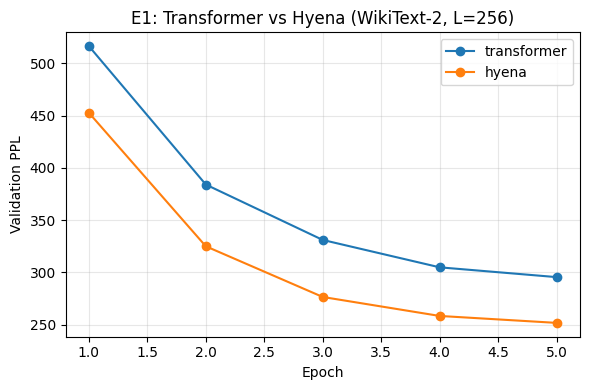

In [20]:
import glob, pandas as pd, matplotlib.pyplot as plt

for f in sorted(glob.glob('results/*.csv')):
    print('\n===', f, '===')
    display(pd.read_csv(f))

# Plot val PPL theo epoch cho 2 model E1
plt.figure(figsize=(6,4))
for model in ['transformer', 'hyena']:
    fp = f'results/E1_{model}_L256.csv'
    try:
        df = pd.read_csv(fp)
        plt.plot(df['epoch'], df['val_ppl'], marker='o', label=model)
    except FileNotFoundError:
        print('Chưa có', fp)
plt.xlabel('Epoch'); plt.ylabel('Validation PPL'); plt.title('E1: Transformer vs Hyena (WikiText-2, L=256)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('results/plots/E1_ppl.png', dpi=120)
plt.show()

## 6. Tải kết quả về máy

In [21]:
!zip -r -q results.zip results
from google.colab import files
files.download('results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>